In [ ]:
# Anti-Money Laundering (AML) Transaction Monitoring Analysis

This project analyzes financial transaction data to identify potential money laundering activity using rule-based detection techniques.

Key indicators include:
- Large transactions
- Structuring behavior (transactions just below reporting thresholds)
- High transaction frequency
- Rapid movement of funds (layering)

A risk scoring model was developed to classify accounts into low, medium, and high risk categories.

In [2]:
# Load dataset (sampled for performance during development)
import pandas as pd

df = pd.read_csv(
    "PS_20174392719_1491204439457_log.csv",
    nrows=200000
)

df.shape

(200000, 11)

In [3]:
# Basic data overview (structure and summary statistics)
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            200000 non-null  int64  
 1   type            200000 non-null  object 
 2   amount          200000 non-null  float64
 3   nameOrig        200000 non-null  object 
 4   oldbalanceOrg   200000 non-null  float64
 5   newbalanceOrig  200000 non-null  float64
 6   nameDest        200000 non-null  object 
 7   oldbalanceDest  200000 non-null  float64
 8   newbalanceDest  200000 non-null  float64
 9   isFraud         200000 non-null  int64  
 10  isFlaggedFraud  200000 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 16.8+ MB


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,200000.00000,2.000000e+05,2.000000e+05,2.000000e+05,2.000000e+05,2.000000e+05,200000.000000,200000.0
mean,10.06589,1.808112e+05,8.821957e+05,9.001938e+05,9.411592e+05,1.191866e+06,0.000735,0.0
std,2.12174,3.291800e+05,2.766264e+06,2.803759e+06,2.373010e+06,2.655236e+06,0.027101,0.0
min,1.00000,3.200000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
25%,9.00000,1.201612e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
50%,10.00000,6.872104e+04,1.951000e+04,0.000000e+00,5.055850e+04,1.320839e+05,0.000000,0.0
75%,12.00000,2.290791e+05,1.915686e+05,2.275212e+05,7.645361e+05,1.189164e+06,0.000000,0.0
max,13.00000,1.000000e+07,3.893942e+07,3.894623e+07,3.903958e+07,3.904248e+07,1.000000,0.0


In [4]:
# Fraud distribution analysis (important for AML context)
df['isFraud'].value_counts()

isFraud
0    199853
1       147
Name: count, dtype: int64

In [5]:
# Structuring / Smurfing Detection (Transactions just below reporting threshold)
structuring_txns = df[(df['amount'] >= 9000) & (df['amount'] <= 10000)]

# Identify accounts with repeated structuring behavior
structuring_txns.groupby('nameOrig').size().sort_values(ascending=False).head()

nameOrig
C100072299    1
C372013621    1
C368725333    1
C369008492    1
C369121998    1
dtype: int64

In [6]:
# High Transaction Frequency Accounts (Potential Suspicious Activity)
txn_counts = df.groupby('nameOrig').size().reset_index(name='txn_count')

txn_counts.sort_values(by='txn_count', ascending=False).head()

,nameOrig,txn_count
173368,C745009740,2
122825,C260230637,2
142013,C44568807,2
73007,C1709295811,2
133325,C361604284,1


In [7]:
# Rapid Movement of Funds (Potential Layering Activity)
df['rapid_txn'] = df.groupby('nameOrig')['step'].diff().fillna(0)

df['rapid_flag'] = df['rapid_txn'] < 2

df[['nameOrig', 'step', 'rapid_txn', 'rapid_flag']].head()

,nameOrig,step,rapid_txn,rapid_flag
0,C1231006815,1,0.0,True
1,C1666544295,1,0.0,True
2,C1305486145,1,0.0,True
3,C840083671,1,0.0,True
4,C2048537720,1,0.0,True


In [8]:
# Count of structuring transactions per account
df['structuring_count'] = df.groupby('nameOrig')['amount'].transform(
    lambda x: ((x >= 9000) & (x <= 10000)).sum()
)

df['structuring_flag'] = df['structuring_count'] > 3

df[['nameOrig', 'amount', 'structuring_count', 'structuring_flag']].head()

,nameOrig,amount,structuring_count,structuring_flag
0,C1231006815,9839.64,1,False
1,C1666544295,1864.28,0,False
2,C1305486145,181.00,0,False
3,C840083671,181.00,0,False
4,C2048537720,11668.14,0,False


In [9]:
# Risk classification based on transaction amount
df['risk_flag'] = "Low"

df.loc[df['amount'] > 10000, 'risk_flag'] = "High"
df.loc[(df['amount'] >= 9000) & (df['amount'] <= 10000), 'risk_flag'] = "Medium"

df['risk_flag'].value_counts()

risk_flag
High      156597
Low        39895
Medium      3508
Name: count, dtype: int64

In [10]:
# Aggregate account-level risk indicators
account_risk = df.groupby('nameOrig').agg({
    'amount': ['sum', 'mean', 'count'],
    'structuring_flag': 'max',
    'rapid_flag': 'max'
}).reset_index()

account_risk.columns = ['nameOrig', 'total_amt', 'avg_amt', 'txn_count', 'structuring', 'rapid']

account_risk.head()

,nameOrig,total_amt,avg_amt,txn_count,structuring,rapid
0,C1000012640,367527.28,367527.28,1,False,True
1,C1000028246,77106.69,77106.69,1,False,True
2,C1000037689,451174.06,451174.06,1,False,True
3,C1000039823,7781.12,7781.12,1,False,True
4,C100006673,363683.60,363683.60,1,False,True


In [11]:
# Risk scoring system (mimics real AML monitoring systems)
account_risk['risk_score'] = 0

account_risk.loc[account_risk['total_amt'] > 50000, 'risk_score'] += 2
account_risk.loc[account_risk['txn_count'] > 50, 'risk_score'] += 2
account_risk.loc[account_risk['structuring'] == True, 'risk_score'] += 3
account_risk.loc[account_risk['rapid'] == True, 'risk_score'] += 2

account_risk['risk_level'] = pd.cut(
    account_risk['risk_score'],
    bins=[-1, 2, 5, 10],
    labels=['Low', 'Medium', 'High']
)

account_risk[['nameOrig', 'risk_score', 'risk_level']].head()

,nameOrig,risk_score,risk_level
0,C1000012640,4,Medium
1,C1000028246,4,Medium
2,C1000037689,4,Medium
3,C1000039823,2,Low
4,C100006673,4,Medium


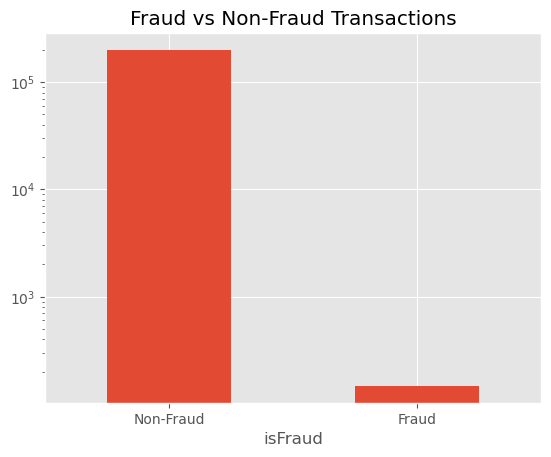

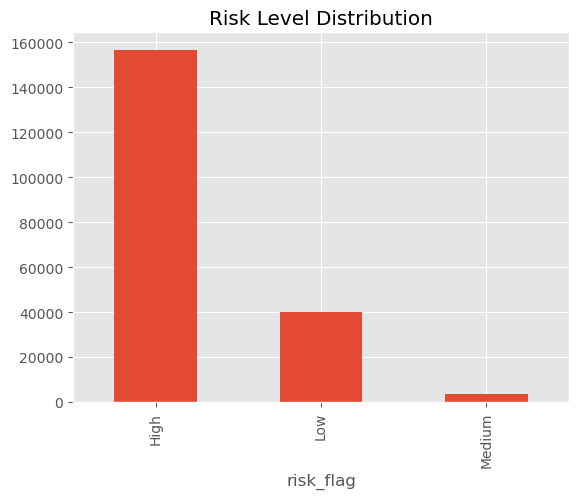

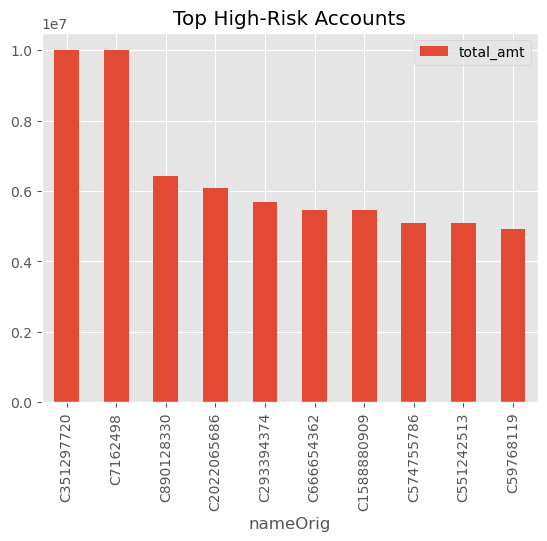

In [17]:
# Import visualization libraries
import matplotlib.pyplot as plt

# Use a clean style
plt.style.use('ggplot')


# 1. # Fraud vs Non-Fraud Distribution (Improved Visibility)
df['isFraud'].value_counts().sort_index().plot(
    kind='bar',
    title='Fraud vs Non-Fraud Transactions'
)

plt.xticks([0, 1], ['Non-Fraud', 'Fraud'], rotation=0)
plt.yscale('log')  # makes small fraud bar visible

plt.show()


# 2. Risk Level Distribution (AML Rule-Based Classification)
df['risk_flag'].value_counts().plot(
    kind='bar',
    title='Risk Level Distribution'
)
plt.show()


# 3. Top High-Risk Accounts (by Total Transaction Amount)
account_risk.sort_values(by='total_amt', ascending=False).head(10).plot(
    x='nameOrig',
    y='total_amt',
    kind='bar',
    title='Top High-Risk Accounts'
)
plt.show()

In [12]:
# NOTE:
# This project applies rule-based AML detection techniques to identify suspicious transaction patterns.
# Key indicators include:
# - Large transactions
# - Structuring behavior (transactions just below reporting thresholds)
# - High transaction frequency
# - Rapid movement of funds (layering)
#
# A risk scoring model was developed to classify accounts into Low, Medium, and High risk categories,
# similar to transaction monitoring systems used in financial institutions.

In [19]:
# Create smaller dataset for BigQuery upload (50,000 rows)
df.sample(50000).to_csv("transactions_sample.csv", index=False)